#TASK-1 : Data Loading, Merging & Exploratory Analysis

In [4]:
#import libaries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Load dataset

trans=pd.read_csv("train_identity.csv")
identity=pd.read_csv("train_transaction.csv")

In [6]:
#Merge dataset

df=trans.merge(identity,on='TransactionID',how='left')

In [7]:
#Basic Operations

df.shape

(144233, 434)

In [8]:
df.columns

Index(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_07', 'id_08', 'id_09',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=434)

In [9]:
df.dtypes

TransactionID      int64
id_01            float64
id_02            float64
id_03            float64
id_04            float64
                  ...   
V335             float64
V336             float64
V337             float64
V338             float64
V339             float64
Length: 434, dtype: object

In [10]:
df.head(10)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2987017,-5.0,61141.0,3.0,0.0,3.0,0.0,NaN,NaN,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2987022,-15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2987038,0.0,31964.0,0.0,0.0,0.0,-10.0,NaN,NaN,0.0,...,0.0,0.0,145.0,25.0,0.0,145.0,25.0,0.0,0.0,0.0
8,2987040,-10.0,116098.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2987048,-5.0,257037.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#Target column Analysis

df['isFraud'].value_counts()

isFraud
0    132915
1     11318
Name: count, dtype: int64

In [12]:
df['isFraud'].value_counts(normalize=True)*100 # Check percentage

isFraud
0    92.152975
1     7.847025
Name: proportion, dtype: float64

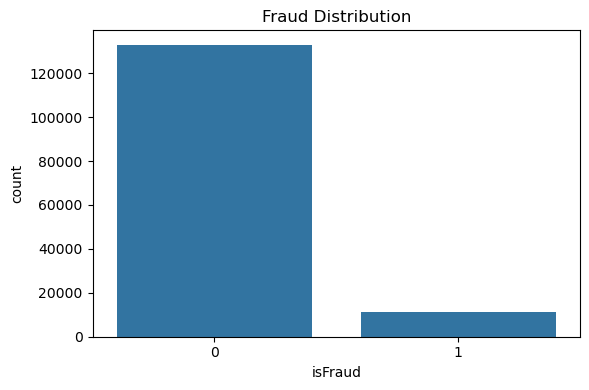

In [13]:
#Visualise Class Imbalance

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud',data=df)
plt.title("Fraud Distribution")
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Fraud Distribution")
#plt.show()

In [14]:
#Find missing Values

missing=df.isnull().mean()*100 #percentage

In [15]:
#Sort Values

missing.sort_values(ascending=True)

TransactionID       0.0
id_01               0.0
TransactionAmt      0.0
isFraud             0.0
card1               0.0
                  ...  
M8                100.0
M7                100.0
M6                100.0
M5                100.0
dist1             100.0
Length: 434, dtype: float64

In [16]:
#Drop columns with >50% missing values

drop_cols=missing[missing>50].index

In [17]:
len(drop_cols)

129

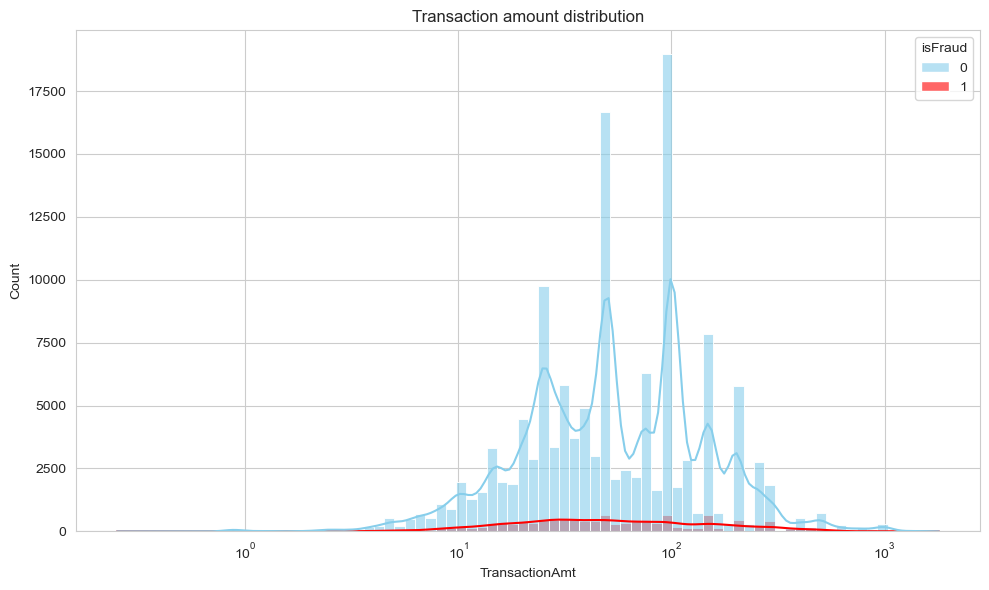

In [18]:
#Transaction Amount Distribution

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="TransactionAmt",hue='isFraud',bins=80,log_scale=True,kde=True,palette=["skyblue","red"],alpha=0.6)
plt.title("Transaction amount distribution")
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Transaction amount distribution")
#plt.show()

In [19]:
#Select numerical column

num_cols=df.select_dtypes(include='number')

In [20]:
#Correlate features with fraud

corr=num_cols.corr()['isFraud'].abs().sort_values(ascending=False)

In [21]:
#Top 20 

top20=corr.index[1:21]

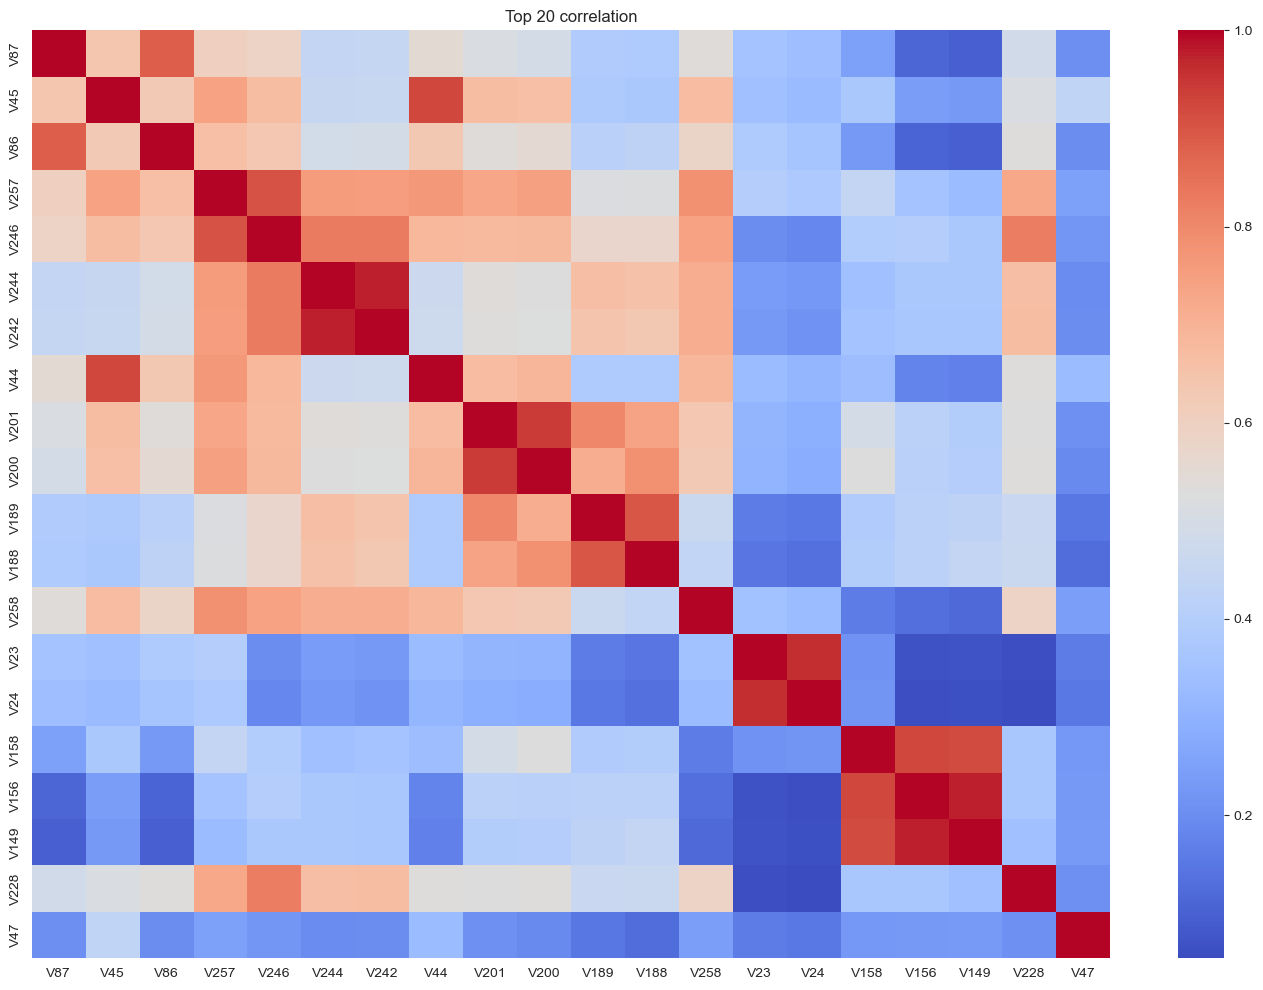

In [22]:
#Correlation HeatMap

plt.figure(figsize=(14,10))
sns.heatmap(df[top20].corr(), cmap='coolwarm')
plt.title("Top 20 correlation")
plt.tight_layout()
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Top 20 correlation")
#plt.show()

#TASK 2: Preprocessing, Imbalance Handling & Feature Engineering

In [23]:
#Drop high missing columns 

df = df.drop(columns=drop_cols)

In [24]:
#Seperate Numerical And Categorical Column

num_cols=df.select_dtypes(include='number').columns #Numerical

In [25]:
cat_cols=df.select_dtypes(include='object').columns #Categorical

In [26]:
#Impute Missing Values

from sklearn.impute import SimpleImputer

In [27]:
median_imp=SimpleImputer(strategy='median')
df[num_cols]=median_imp.fit_transform(df[num_cols])

In [28]:
mode_imp=SimpleImputer(strategy='most_frequent')
df[cat_cols]=mode_imp.fit_transform(df[cat_cols])

In [29]:
#Label Encoding

from sklearn.preprocessing import LabelEncoder

In [30]:
for col in cat_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str))

Label Encoding was choosen because dataset contains many high-cardinality categorical values

In [31]:
#Feature Engineering

#Amount Ratio
df['AmtToMeanRatio']=df['TransactionAmt']/df['TransactionAmt'].mean()

C:\Users\DELL WORKSTATION\AppData\Local\Temp\ipykernel_19376\468246415.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AmtToMeanRatio']=df['TransactionAmt']/df['TransactionAmt'].mean()


In [32]:
#Log Transaction Amount

df['LogTransactionAmt']=np.log1p(df['TransactionAmt'])

C:\Users\DELL WORKSTATION\AppData\Local\Temp\ipykernel_19376\1174319176.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['LogTransactionAmt']=np.log1p(df['TransactionAmt'])


In [33]:
#Hour Of Day

df['HourOfDay']=(df['TransactionDT']//3600)%24

C:\Users\DELL WORKSTATION\AppData\Local\Temp\ipykernel_19376\398667134.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HourOfDay']=(df['TransactionDT']//3600)%24


In [34]:
#Night Transaction

df['IsNight']=((df['HourOfDay']>=0)&(df['HourOfDay']<=6)).astype(int)

C:\Users\DELL WORKSTATION\AppData\Local\Temp\ipykernel_19376\2201756091.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IsNight']=((df['HourOfDay']>=0)&(df['HourOfDay']<=6)).astype(int)


In [35]:
#Device Risk

df['DeviceRisk']=((df['DeviceType']=='mobile')|(df['DeviceInfo'].notnull())).astype(int)

C:\Users\DELL WORKSTATION\AppData\Local\Temp\ipykernel_19376\340565170.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DeviceRisk']=((df['DeviceType']=='mobile')|(df['DeviceInfo'].notnull())).astype(int)


In [36]:
#Email Domain Match 

df['EmailDomainMatch']=(df['P_emaildomain']==df['R_emaildomain']).astype(int)

C:\Users\DELL WORKSTATION\AppData\Local\Temp\ipykernel_19376\2851225120.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['EmailDomainMatch']=(df['P_emaildomain']==df['R_emaildomain']).astype(int)


In [37]:
#Split features and Target
X=df.drop('isFraud',axis=1)
Y=df['isFraud']

In [38]:
#Train test split

from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [40]:
#Apply SMOTE

from imblearn.over_sampling import SMOTE

In [41]:
sm=SMOTE(random_state=42)
X_train_sm,Y_train_sm=sm.fit_resample(X_train,Y_train)

C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL WORKSTATION\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL WORKSTATION\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fd

In [42]:
#Compare Class Ratio

Y_train.value_counts()

isFraud
0.0    106332
1.0      9054
Name: count, dtype: int64

In [43]:
Y_train_sm.value_counts()

isFraud
1.0    106332
0.0    106332
Name: count, dtype: int64

In [44]:
#Scale Data

from sklearn.preprocessing import RobustScaler

In [45]:

scaler=RobustScaler()
X_train_sm=scaler.fit_transform(X_train_sm)
X_test=scaler.transform(X_test)

**RobustScalar works well with outliners**

#TASK 3:Model Training, Comparison & Threshold Optimization

In [46]:
from sklearn.metrics import *

In [47]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [48]:
#Train LightGBM
from lightgbm import LGBMClassifier

In [49]:
lgb=LGBMClassifier()

In [50]:
#Train
lgb.fit(X_train_sm,Y_train_sm)

[LightGBM] [Info] Number of positive: 106332, number of negative: 106332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.559704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72382
[LightGBM] [Info] Number of data points in the train set: 212664, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier()

In [51]:
#Predict
pred_lgb=lgb.predict(X_test)
prob_lgb=lgb.predict_proba(X_test)[:,1]

C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [52]:
!pip install xgboost

In [53]:
#Train XGBClassifier

from xgboost import XGBClassifier

In [54]:
xgb=XGBClassifier(random_state=42,eval_metric='logloss')

In [55]:
xgb.fit(X_train_sm,Y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [56]:
pred_xgb=xgb.predict(X_test)
prob_xgb=xgb.predict_proba(X_test)[:,1]

In [57]:
#Isolation Forest

from sklearn.ensemble import IsolationForest

In [58]:
iso=IsolationForest(contamination=0.035,
                    random_state=42)

In [59]:
iso.fit(X_train_sm)

IsolationForest(contamination=0.035, random_state=42)

In [60]:
pred_iso=iso.predict(X_test)
pred_iso=np.where(pred_iso==-1,1,0)

In [61]:
#create evaluation function

def evaluate_model(Y_true,pred,prob,name):
     print(f"Model:{name}")
     print("Accuracy",accuracy_score(Y_true,pred))
     print("Precision",(Y_true,pred))
     print("Recall:",recall_score(Y_true,pred))
     print("F1",f1_score(Y_true,pred))
     print("ROC AUC:",roc_auc_score(Y_true,prob))
     print("PR AUC:",average_precision_score(Y_true,prob))

In [62]:
#LightGBM

evaluate_model(
    Y_test,
    pred_lgb,
    prob_lgb,
    "LightGBM"
)

Model:LightGBM
Accuracy 0.9653690158422019
Precision (38776     0.0
8870      0.0
109538    0.0
75785     0.0
140473    0.0
         ... 
121134    0.0
62294     0.0
128566    0.0
44421     0.0
18371     0.0
Name: isFraud, Length: 28847, dtype: float64, array([0., 0., 0., ..., 0., 0., 0.]))
Recall: 0.6651943462897526
F1 0.7509349289454001
ROC AUC: 0.960003530511609
PR AUC: 0.8302261750402593


In [63]:
#XGBoost

evaluate_model(
    Y_test,
    pred_xgb,
    prob_xgb,
    "XGBoost"
)

Model:XGBoost
Accuracy 0.9721981488543002
Precision (38776     0.0
8870      0.0
109538    0.0
75785     0.0
140473    0.0
         ... 
121134    0.0
62294     0.0
128566    0.0
44421     0.0
18371     0.0
Name: isFraud, Length: 28847, dtype: float64, array([0, 0, 0, ..., 0, 0, 0]))
Recall: 0.7292402826855123
F1 0.8045808966861598
ROC AUC: 0.9712875095258016
PR AUC: 0.8786790116465814


In [64]:
#Confusion Matrix

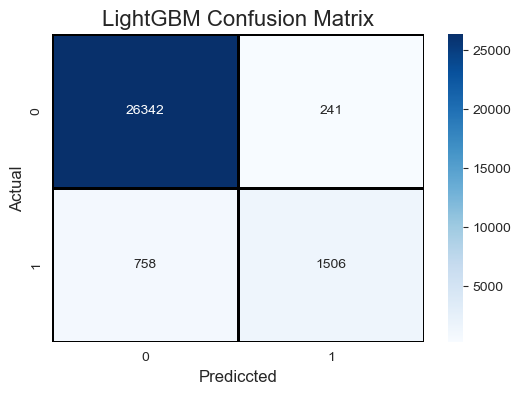

In [65]:
cm=confusion_matrix(Y_test,pred_lgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',linewidth=1,linecolor='black')
plt.title("LightGBM Confusion Matrix",fontsize=16)
plt.xlabel("Prediccted",fontsize=12)
plt.ylabel("Actual",fontsize=12)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Confusion Matrix")
#plt.show()

In [66]:
#ROC Curve
fpr,tpr,_=roc_curve(Y_test,prob_lgb)

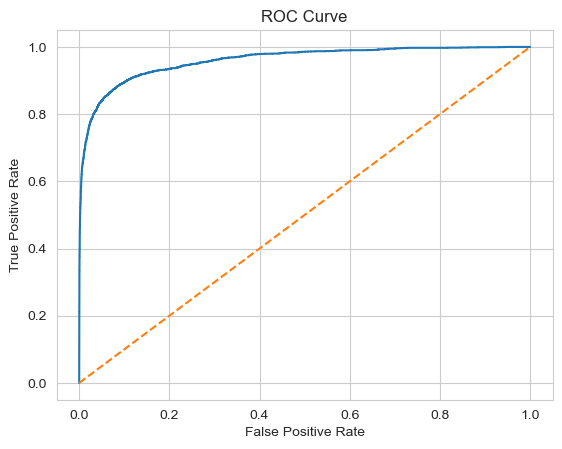

In [67]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\ROC Curve")
#plt.show()

In [68]:
#Precison recall Curve

precision,recall,thresholds=precision_recall_curve(
    Y_test,
    prob_lgb
)

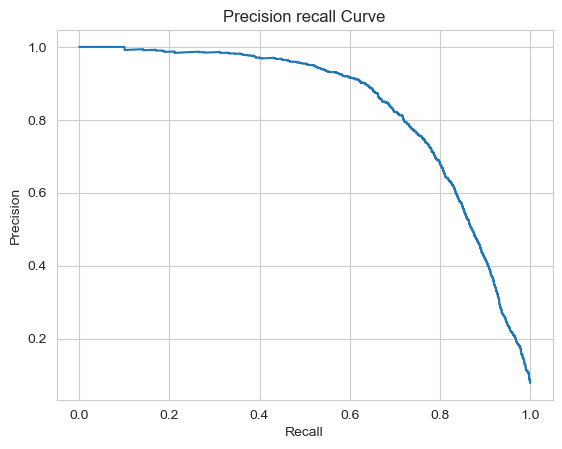

In [69]:
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision recall Curve")
plt.grid(True)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Precision recall Curve")
plt.show()

In [70]:
#Threshold Optimization
from sklearn.metrics import f1_score
import numpy as np

f1_scores = []

# use fewer thresholds for speed
sampled_thresholds = thresholds[::100]

for t in sampled_thresholds:
    
    preds = (prob_lgb >= t).astype(int)
    
    score = f1_score(Y_test, preds)
    
    f1_scores.append(score)

best_idx = np.argmax(f1_scores)

best_threshold = sampled_thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.4140406541096919


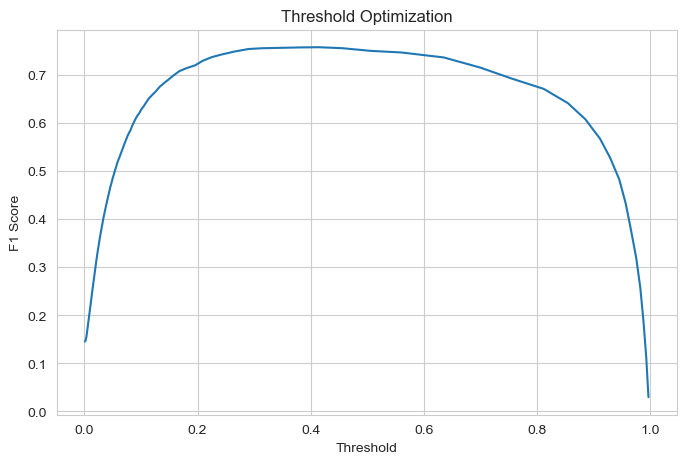

In [71]:
#Threshold vs F1
plt.figure(figsize=(8,5))

plt.plot(sampled_thresholds, f1_scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold Optimization")

plt.grid(True)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Threshold Optimization")
plt.show()

In [72]:
from sklearn.metrics import precision_recall_curve

In [73]:
precision, recall, thresholds = precision_recall_curve(
    Y_test,
    prob_lgb
)

In [74]:
print(len(thresholds))

28634


In [75]:
#Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

In [76]:
params={'n_estimators':[100,200],
        'max_depth':[5,10],
        'learning_rate':[0.01,0.05,0.1]}

In [77]:
#Randomized Search Cv
search=RandomizedSearchCV(lgb,param_distributions=params,n_iter=5,scoring='f1',cv=3,verbose=1)

In [78]:
search.fit(X_train_sm,Y_train_sm)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Number of positive: 70888, number of negative: 70888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.230370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 72358
[LightGBM] [Info] Number of data points in the train set: 141776, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 70888, number of negative: 70888
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.328698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72336
[LightGBM] [Info] Number of data points in the train set: 141776, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 70888, number of negative: 70888
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.443165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72343
[LightGBM] [Info] Number of data points in the train set: 141776, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 70888, number of negative: 70888
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.291698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72343
[LightGBM] [Info] Number of data points in the train set: 141776, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 106332, number of negative: 106332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.476540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72382
[LightGBM] [Info] Number of data points in the train set: 212664, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

RandomizedSearchCV(cv=3, estimator=LGBMClassifier(), n_iter=5,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [5, 10],
                                        'n_estimators': [100, 200]},
                   scoring='f1', verbose=1)

In [79]:
#Best Model
best_model=search.best_estimator_
print(best_model)

LGBMClassifier(max_depth=5)


LightGBM achieved the best balance between recall and precision. After threshold optimization and hyperparameter tuning, the model improved fraud detection capability significantly while reducing false negatives.

#TASK 4:Explainable AI (SHAP)

In [80]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [81]:
import shap

In [82]:
#Create SHAP Explainer
explainer=shap.TreeExplainer(lgb)

In [83]:
#Generate SHAP Values
shap_values=explainer.shap_values(X_test)

C:\Users\DELL WORKSTATION\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


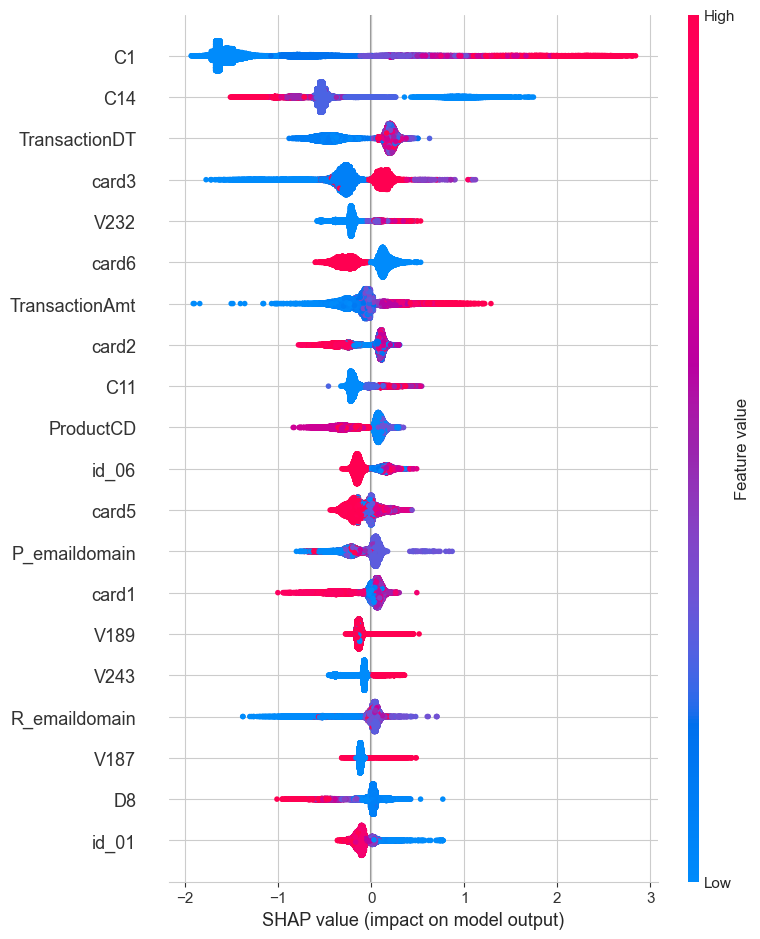

In [120]:
shap.summary_plot(shap_values,X_test,show=False)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Shap_summary")

In [85]:
fraud_idx=np.argmax(prob_lgb)

In [86]:
border_idx=np.argmin(np.abs(prob_lgb-0.5))

In [87]:
legit_idx=np.argmin(prob_lgb)

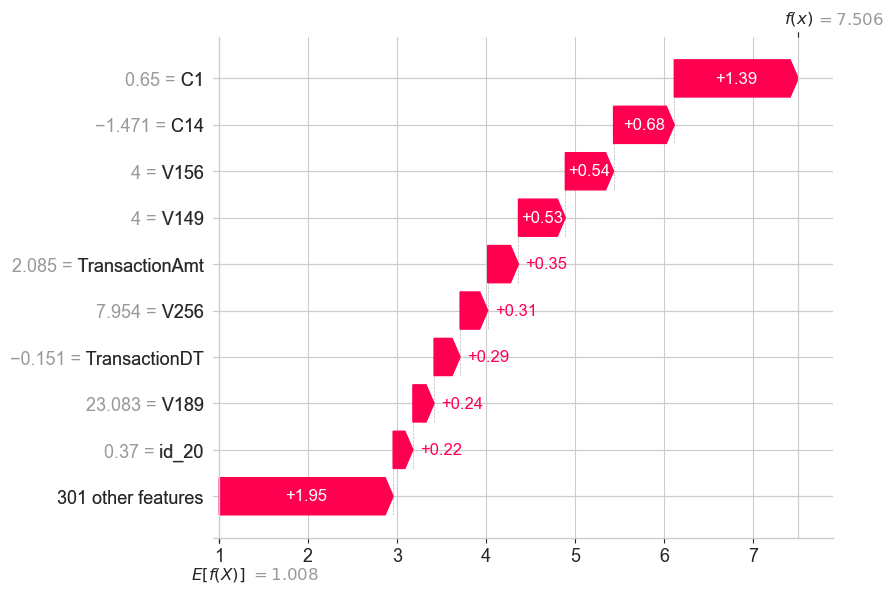

In [88]:
#Fraud Case
shap.plots.waterfall(shap.Explanation(
    values=shap_values[fraud_idx],
    base_values=explainer.expected_value,
    data=X_test[fraud_idx],
    feature_names=X.columns))

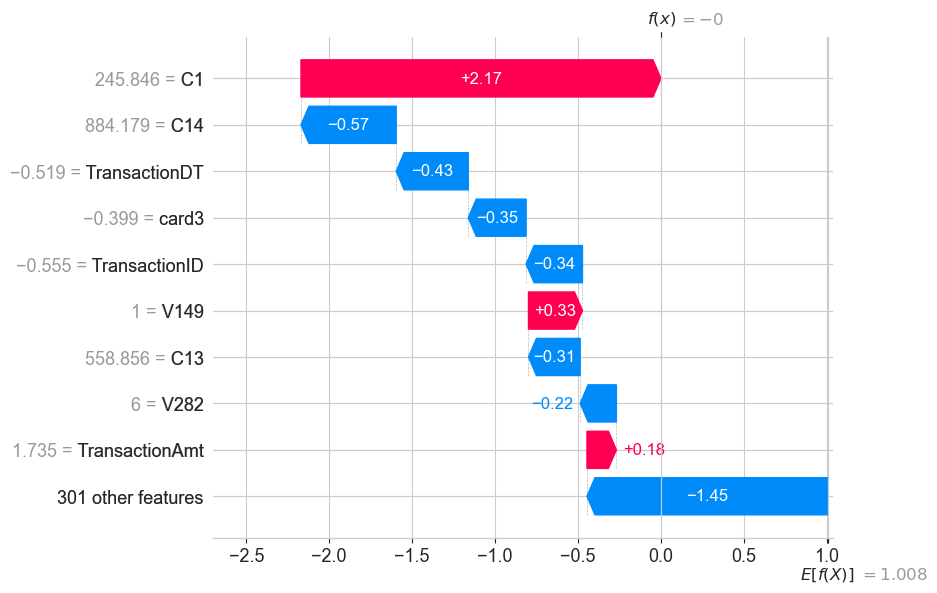

In [89]:
#Boderline Case

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[border_idx],
        base_values=explainer.expected_value,
        data=X_test[border_idx],
        feature_names=X.columns))

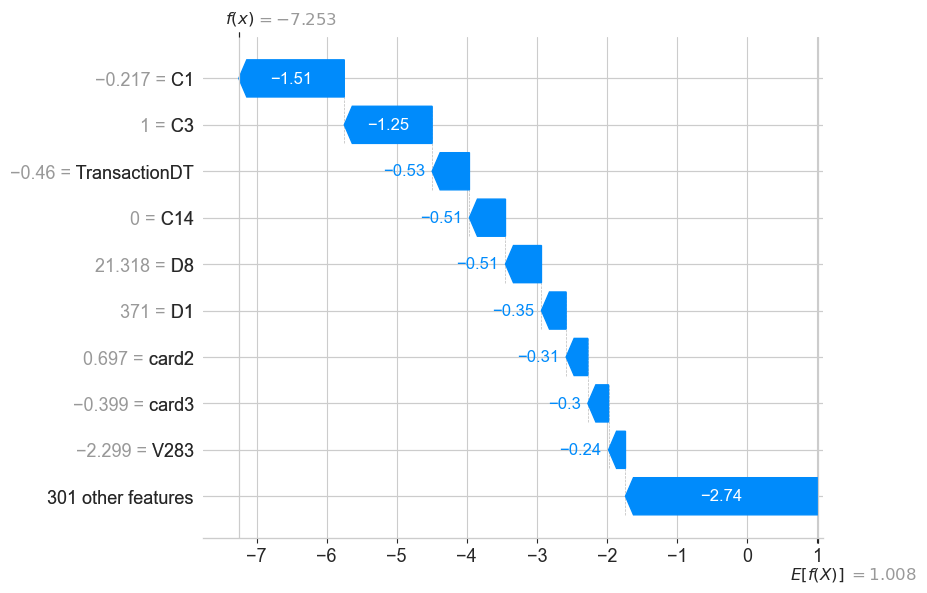

In [90]:
#Legimate Transactions

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[legit_idx],
        base_values=explainer.expected_value,
        data=X_test[legit_idx],
        feature_names=X.columns))

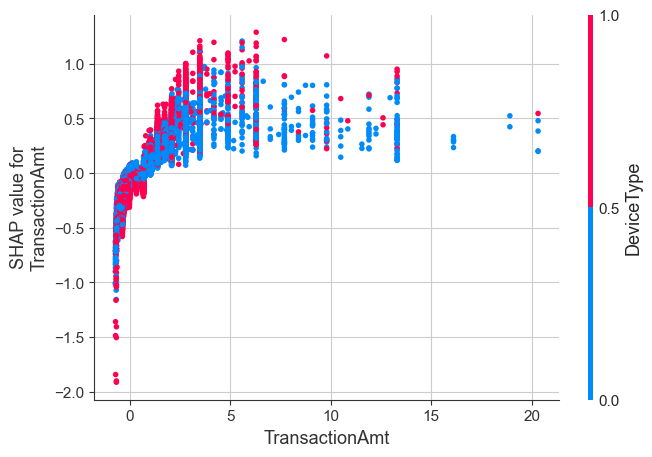

In [94]:
#Shap Dependence

shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test,
    show=False)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Shap dependency")

In [92]:
X_train_sm = pd.DataFrame(
    X_train_sm,
    columns=X.columns
)

X_test = pd.DataFrame(
    X_test,
    columns=X.columns
)

In [93]:
X_test.columns

Index(['TransactionID', 'id_01', 'id_02', 'id_05', 'id_06', 'id_09', 'id_10',
       'id_11', 'id_12', 'id_13',
       ...
       'V336', 'V337', 'V338', 'V339', 'AmtToMeanRatio', 'LogTransactionAmt',
       'HourOfDay', 'IsNight', 'DeviceRisk', 'EmailDomainMatch'],
      dtype='object', length=310)

#Compare SHAP Importance vs Model Importance 

In [95]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_model.feature_importances_})

In [96]:
importance.sort_values(
    by='Importance',
    ascending=False).head(10)

,Feature,Importance
42,C1,180
55,C14,127
30,TransactionAmt,85
0,TransactionID,72
34,card3,68
41,R_emaildomain,58
33,card2,57
54,C13,52
1,id_01,48
19,id_31,47


#TASK 5:Risk Segmentation

In [97]:
#Use false probabilities

prob_lgb

array([0.00624723, 0.01412801, 0.02811514, ..., 0.01117686, 0.0174294 ,
       0.0371687 ])

In [98]:
print(prob_lgb[:5])

[0.00624723 0.01412801 0.02811514 0.02144977 0.02615421]


In [99]:
#Create conditions
conditions=[prob_lgb>=0.75,
            (prob_lgb>=0.40)&(prob_lgb<0.75),
            prob_lgb<0.40]

In [100]:
#create Labels

choices=['Critical','Suspicious','Clear']

In [101]:
#Create Risk Tier
df_risk=X_test.copy()

In [102]:
df_risk['FraudProbability']=prob_lgb

In [103]:
df_risk['RiskTier']=np.select(conditions,choices,default='clear')

In [104]:
df_risk[['FraudProbability','RiskTier']].head()

,FraudProbability,RiskTier
0,0.006247,Clear
1,0.014128,Clear
2,0.028115,Clear
3,0.021450,Clear
4,0.026154,Clear


In [105]:
risk_counts=df_risk['RiskTier'].value_counts()
print(risk_counts)

RiskTier
Clear         26862
Critical       1348
Suspicious      637
Name: count, dtype: int64


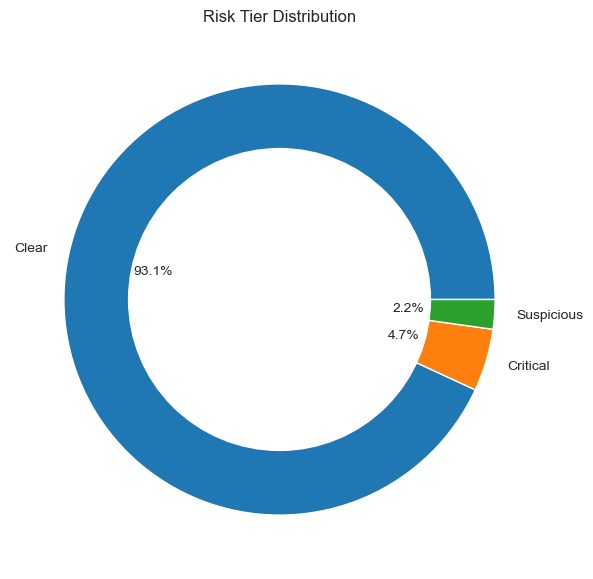

In [106]:
#Donut Chart
plt.figure(figsize=(7,7))
plt.pie(risk_counts,labels=risk_counts.index,autopct='%1.1f%%')
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig=plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Risk Tier Distribution")
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Risk Tier Distribution")
#plt.show()

In [ ]:
#Analyze average Transaction amount

In [107]:
avg_amt=df_risk.groupby('RiskTier')['TransactionAmt'].mean()
print(avg_amt)

RiskTier
Clear         0.443158
Critical      0.484966
Suspicious    0.522882
Name: TransactionAmt, dtype: float64


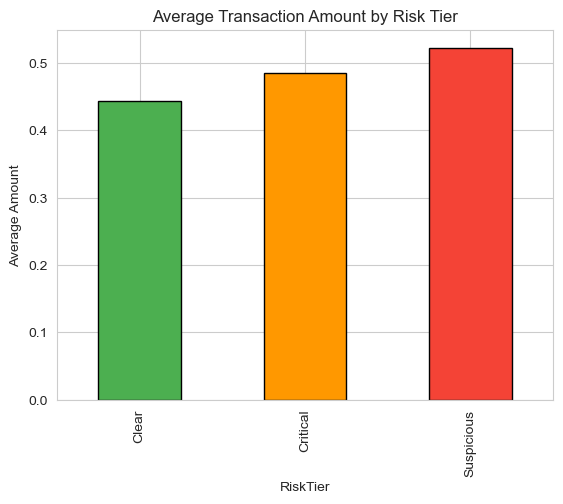

In [108]:
#Average Amount Visualization
colors=['#4CAF50','#FF9800','#F44336']
avg_amt.plot(kind='bar',edgecolor='black',color=colors)
plt.title("Average Transaction Amount by Risk Tier")
plt.ylabel("Average Amount")
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Average Transaction Amount by Risk Tier")
plt.show()
plt.show()

In [109]:
#Device Distribution
device_dist=pd.crosstab(df_risk['DeviceType'],df_risk['RiskTier'])
print(device_dist)

RiskTier    Clear  Critical  Suspicious
DeviceType                             
0.0         16629       673         341
1.0         10233       675         296


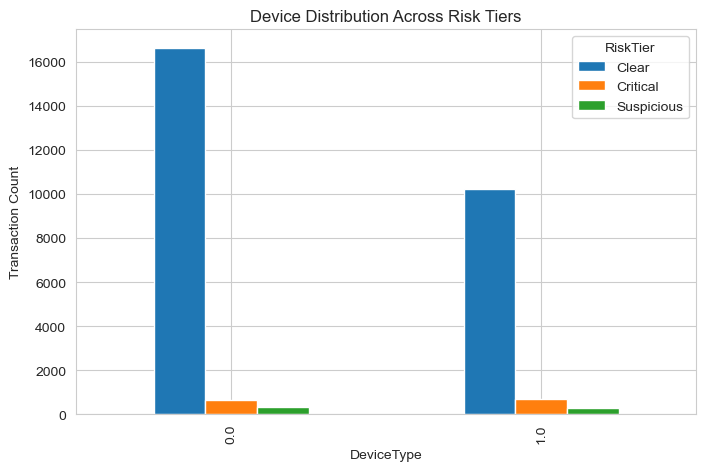

In [110]:
device_dist.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Device Distribution Across Risk Tiers")
plt.ylabel("Transaction Count")
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Device Distribution Across Risk Tiers")
plt.show()

In [111]:
hour_pattern = df_risk.groupby('HourOfDay')['FraudProbability'].mean()

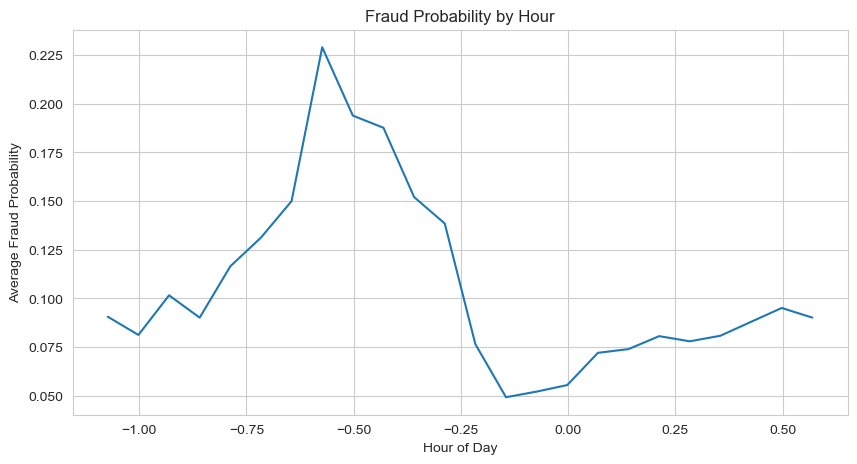

In [112]:
plt.figure(figsize=(10,5))
plt.plot(hour_pattern)
plt.title("Fraud Probability by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fraud Probability")
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Fraud Probability by Hour")
plt.show()

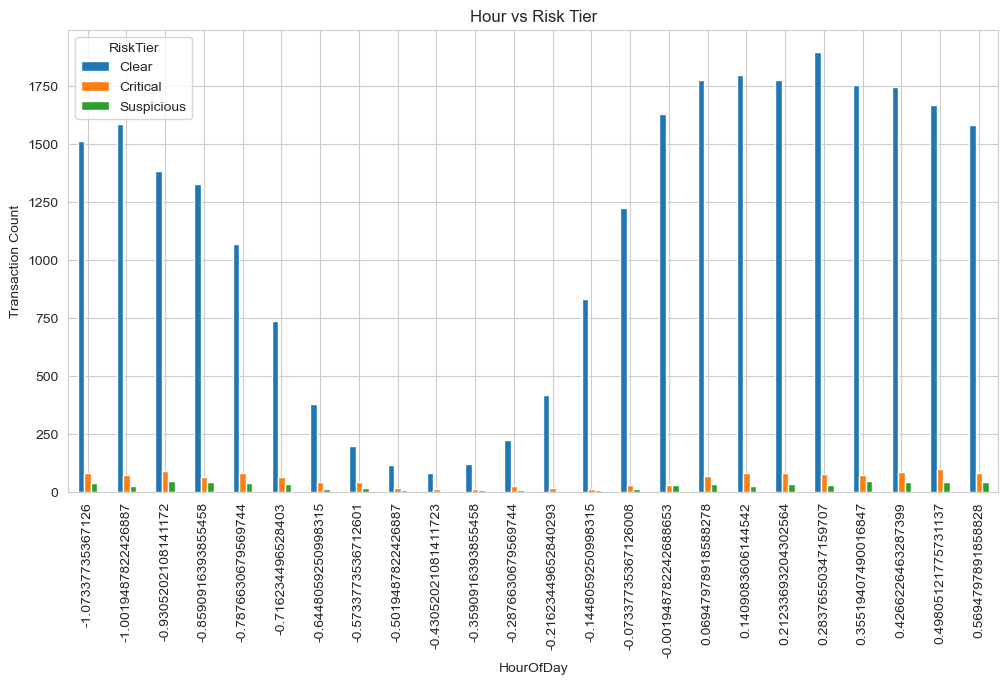

In [113]:
tier_hour = pd.crosstab(
    df_risk['HourOfDay'],
    df_risk['RiskTier']
)

tier_hour.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Hour vs Risk Tier")

plt.ylabel("Transaction Count")
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Grouped Bar Chart")
plt.show()

In [114]:
critical_df = df_risk[ df_risk['RiskTier'] == 'Critical']

In [115]:
critical_df['TransactionAmt'].describe()

count    1348.000000
mean        0.484966
std         1.530761
min        -0.653668
25%        -0.397636
50%        -0.072367
75%         0.683249
max        20.313268
Name: TransactionAmt, dtype: float64

In [116]:
critical_df['HourOfDay'].value_counts()

HourOfDay
 0.498051    101
-0.930520     89
 0.426623     87
 0.212337     83
-0.787663     81
 0.569480     81
-1.073377     80
 0.140908     80
 0.283766     78
-1.001949     74
 0.355194     74
 0.069480     68
-0.716234     63
-0.859092     63
-0.644806     45
-0.573377     44
-0.001949     32
-0.073377     28
-0.287663     24
-0.216234     19
-0.501949     17
-0.144806     13
-0.430520     12
-0.359092     12
Name: count, dtype: int64

In [117]:
critical_df['DeviceType'].value_counts()

DeviceType
1.0    675
0.0    673
Name: count, dtype: int64

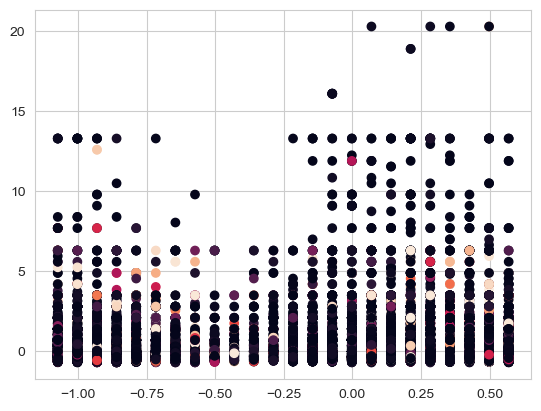

In [118]:
#extra
plt.scatter(
    df_risk['HourOfDay'],
    df_risk['TransactionAmt'],
    c=df_risk['FraudProbability'],
)
plt.savefig(r"C:\Users\DELL WORKSTATION\OneDrive\Desktop\Fraud_Detection_[Tanisha Poojary]\charts\Scatter Plot")

In [ ]:
import joblib

In [ ]:
joblib.dump( best_model,"model.pkl")

In [ ]:
df_risk.to_csv("processed_data.csv", index=False)

#Task 8:Insights and Business Recommendations

1. Which Model Performed Best and Why?

Among all the models tested, the **LightGBM Classifier** performed best overall. It achieved the highest balance between Precision, Recall, F1-Score, ROC-AUC, and PR-AUC compared to XGBoost and Isolation Forest.<br>
The reasons for its superior performance are:<br>
LightGBM efficiently handles large-scale and high-dimensional datasets.<br>
It performs well on highly imbalanced fraud datasets.<br>
Faster training speed and lower memory usage.<br>
Better ability to capture complex fraud patterns.<br>
Produced more stable probability scores for threshold optimization.<br>
Although XGBoost also performed strongly, LightGBM provided slightly better fraud recall and PR-AUC, which are critical for fraud detection systems.
Isolation Forest was useful for anomaly detection but underperformed compared to supervised learning models because it does not directly learn fraud labels.<br>

2. Why PR-AUC Matters More Than Accuracy in Fraud Detection?<br>
In fraud detection, the dataset is highly imbalanced because fraudulent transactions represent only a very small percentage of total transactions.<br>
A model can achieve very high accuracy simply by predicting all transactions as non-fraudulent. For example:<br>
96% accuracy may still miss most fraud cases.<br>
Missing fraud transactions can cause major financial losses.<br>
Therefore, Precision-Recall AUC (PR-AUC) is more important because:<br>
Precision measures how many predicted frauds are actually fraud.<br>
Recall measures how many actual fraud cases are detected.<br>
PR-AUC focuses specifically on minority class performance.<br>
**A higher PR-AUC indicates the model is effective at detecting fraud while minimizing false alarms**<br>

3. Top 3 Fraud Signals Identified by SHAP<br>
SHAP analysis revealed the following major fraud indicators:<br>
1. High Transaction Amount<br>
Fraudulent transactions often involved unusually high transaction amounts compared to normal customer behavior.<br>
2. Suspicious Device Usage<br>
Transactions originating from uncommon or risky device types showed significantly higher fraud probability.<br>
3. Abnormal Transaction Timing<br>
Transactions occurring during unusual hours demonstrated increased fraud likelihood.<br>
These SHAP explanations improved model transparency and helped explain predictions to non-technical stakeholders.<br>

4. Common Characteristics of Critical Risk Transactions<br>
Critical Risk transactions showed several recurring patterns:<br>
High transaction amounts<br>
Unusual transaction timing<br>
Suspicious device information<br>
Elevated fraud probability scores<br>
Repeated abnormal customer behavior patterns<br>
Most critical-risk transactions were concentrated during specific hours and frequently originated from risky devices.<br>

5. Two Actionable Fraud Prevention Policies<br>
**Policy 1 — Real-Time Transaction Blocking**
Automatically flag or temporarily block transactions with fraud probability above a predefined threshold until manual verification is completed.<br>
**Policy 2 — Device-Based Authentication**<br>
Require additional authentication (OTP or multi-factor authentication) for transactions originating from suspicious or previously unseen devices.
These policies can significantly reduce financial fraud losses while improving transaction security.<br>

6. Estimated Money Saved Annually
By deploying the fraud detection system in real time, financial institutions can potentially prevent a large percentage of fraudulent transactions before completion.<br>
Assuming even a moderate fraud reduction rate, the system could save millions of dollars annually by:<br>
Reducing unauthorized transactions<br>
Lowering investigation costs<br>
Minimizing chargebacks<br>
Preventing identity theft losses<br>
The exact savings depend on transaction volume and fraud exposure levels.<br>

7. Model Limitations<br>
Despite strong performance, the model still has several limitations:<br>
False positives may inconvenience legitimate customers.<br>
Fraud patterns evolve continuously over time.<br>
Model performance may degrade without periodic retraining.<br>
Some fraud cases may remain undetected due to limited behavioral features.<br>
SHAP explanations increase computational overhead.<br>
Continuous monitoring and retraining are required for maintaining effectiveness.<br>

8. Additional Data That Could Improve Performance
The following additional features could improve fraud detection accuracy:<br>
Customer historical behavior patterns<br>
Geolocation and IP address data<br>
Merchant category information<br>
Real-time device fingerprinting<br>
Browser metadata<br>
Network relationship analysis<br>
Transaction sequence patterns<br>
Historical fraud blacklists<br>
Incorporating richer behavioral and contextual information would help the model detect more sophisticated fraud attacks.<br>